# Stage 3 — Initial Clustering

**Input**: Per-ROI feature CSVs from `stage2_features/<machine>/` (or `feature_csv_dir` in config)  
**Output**: `adata.h5ad`, dot plot, heatmap, `top_markers.csv`, per-ROI cluster assignment CSVs  
**Scope**: Per machine — select which machine to cluster below.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display

from pipeline.config import load_config
from pipeline.io import (
    combine_feature_files,
    discover_feature_files,
    save_adata,
    save_roi_assignments,
)
from pipeline.preprocessing import (
    clean_column_names,
    select_features,
    build_adata,
    double_z_norm,
)
from pipeline.clustering import (
    run_leiden_pipeline,
    compute_top_markers,
    prepare_cluster_means,
)
from pipeline.visualization import plot_dotplot, plot_heatmap, plot_spatial

cfg = load_config("config.yaml")
np.random.seed(cfg.clustering.random_seed)

## Select Machine

Set the machine to cluster. Must match a key in `config.yaml → machines`.

In [2]:
# ── Select which machine to process ──
MACHINE = list(cfg.machines.keys())[0]  # Change this or pick from list
print(f"Available machines: {list(cfg.machines.keys())}")
print(f"Selected machine: {MACHINE}")

machine_cfg = cfg.machines[MACHINE]
input_dir = machine_cfg.feature_csv_dir
output_dir = cfg.ensure_stage_dir(3, MACHINE)
print(f"Input dir:  {input_dir}")
print(f"Output dir: {output_dir}")

Available machines: ['machine_A']
Selected machine: machine_A
Input dir:  ./data/raw/mrd
Output dir: experiments/my_experiment/stage3_clustering/machine_A


## Load & Prepare Data

In [5]:
# Discover and load feature files
feature_files, region_list = discover_feature_files(input_dir)
print(f"Found {len(feature_files)} ROI files")

df = combine_feature_files(input_dir, feature_files, region_list)
print(f"Combined shape: {df.shape}")

# Clean column names (strip "Biomarker Exp" suffix)
df = clean_column_names(df)

# Split into selected features, unselected features, metadata
selected_markers = cfg.selected_markers
meta_columns = cfg.meta_columns

selected_feat_exp, unselected_feat_exp, metadata = select_features(
    df, selected_markers, meta_columns
)

print(f"Selected markers: {len(selected_markers)}")
print(f"Unselected features: {len(unselected_feat_exp.columns)}")
display(selected_feat_exp.head())

Found 10 ROI files
Dropping 55 DAPI autofluorescence columns
Combined shape: (59102, 93)
Selected markers: 25
Unselected features: 63


,Arginase 1 REAL1137,CD11b REA1321,CD11c REA1310,CD14 REA1314,CD15 VIMC6,CD16 REA1324,CD163 REA1309,CD20 REAL1069,CD235a REA175,CD3 REAL1097,...,CD68 REAL1346,CD73 REAL1172,CD79a REA1168,CD8a REA1024,FoxP3 REA1253,HLA DR REAL550,Ki 67 REAL1047,Mast Cell Tryptase REAL798,PAX 5 REA140,Podoplanin REA446
0,430.155914,462.412201,638.143372,459.612915,5721.433594,300.721191,242.431900,92.813622,221.759857,33.643368,...,361.770599,849.817200,8.663082,207.883514,60.338711,568.967712,6773.785156,896.876343,36.231182,52.521507
1,3427.325684,8490.462891,1240.837158,960.781738,13943.570312,3465.363037,483.302917,136.172638,1739.824097,120.967430,...,355.061890,1238.622192,165.648209,562.641724,56.506172,369.680786,2480.626465,1189.551514,84.441360,187.084686
2,213.613983,297.294495,355.485870,450.673889,916.261230,266.283752,287.504150,199.146423,67.425957,52.324459,...,104.995010,943.931763,44.342762,256.816986,30.899471,307.412659,1627.280396,758.758911,23.420635,240.242935
3,130.816849,175.453812,211.385742,225.296600,976.961121,139.006729,140.641815,27.278769,70.883308,6.910859,...,83.286873,960.883301,2.476499,135.176666,42.138321,141.790924,1320.514771,791.009460,10.129251,40.170177
4,1039.424194,2707.147217,660.021667,750.134216,8221.302734,977.601807,263.558441,64.991341,11547.484375,33.367966,...,154.740265,903.168823,14.186147,553.735901,75.662498,160.987015,17526.496094,1013.329102,23.033333,92.129868


In [6]:
# Build AnnData (normalises selected features internally)
adata = build_adata(selected_feat_exp, metadata, selected_markers)

# Store unselected features in obs for later use
unselected_features = list(unselected_feat_exp.columns)
for col in unselected_features:
    adata.obs[col] = unselected_feat_exp[col].values

display(adata)

AnnData object with n_obs × n_vars = 59102 × 25
    obs: 'AKT Pan REA676', 'Actin REAL650', 'Alexa647 anti rabbit1', 'BATF REA486', 'Bcl 2 REA872', 'CD104 REA236', 'CD117 REA787', 'CD123 REA918', 'CD134 ACT35', 'CD147 REA282', 'CD181 REA958', 'CD182 REA208', 'CD183 REAL756', 'CD195 REA245', 'CD196 REA190', 'CD1c REAL1005', 'CD2 REA1130', 'CD202b REA198', 'CD204 REA460', 'CD209 REAL690', 'CD223 REA351', 'CD226 REA1040', 'CD23 REAL1096', 'CD244 REAL1225', 'CD247 REAL1135', 'CD271 REAL709', 'CD274 REA1308', 'CD279 PD1 3 1 3', 'CD295 REA361', 'CD305 REA447', 'CD317 REA202', 'CD43 REA833', 'CD44 REA690', 'CD45RA REAL164', 'CD45RO REA611', 'CD52 REA164', 'CD56 REAL1142', 'CD57 REA769', 'CD88 REA1213', 'CD90 REAL677', 'CD99 REA1174', 'Cell Id', 'EZH2 REA907', 'EmptyPE1', 'FAK pS910 REA407', 'FcepsilonRIalpha REA758', 'Galectin 9 REA435', 'IFN gamma REAL788', 'IRF 7 REA521', 'JNK1 REAL1128', 'JNK2 REA1153', 'NPM1mut primaryRab400 polyclonal', 'Nuc X', 'Nuc Y Inv', 'Nucleophosmin REAL823', 'PCN

## Clustering (PCA → KNN → Leiden)

In [7]:
adata = run_leiden_pipeline(
    adata,
    n_neighbors=cfg.clustering.n_neighbors,
    n_pcs=cfg.clustering.n_pcs,
    resolution=cfg.clustering.resolution,
    random_seed=cfg.clustering.random_seed,
)

print(f"\nCluster distribution:")
display(adata.obs["leiden"].value_counts())

2026-02-17 01:23:23.262553: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-02-17 01:23:23.262658: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
/home/hp/projects/multiplex_imaging_analysis/pipeline/clustering.py:44: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=resolution)



Cluster distribution:


leiden
0     5222
1     4454
2     3999
3     3743
4     3393
5     3390
6     3261
7     3198
8     2829
9     2550
10    2540
11    2117
12    2037
13    2025
14    1920
15    1842
16    1487
17    1346
18    1165
19    1120
20    1034
21    1000
22     995
23     755
24     665
25     507
26     270
27     226
28      12
Name: count, dtype: int64

## Visualisation: Dot Plot & Heatmap

/home/hp/projects/multiplex_imaging_analysis/pipeline/clustering.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means = expr_df.groupby(cluster_key).mean()


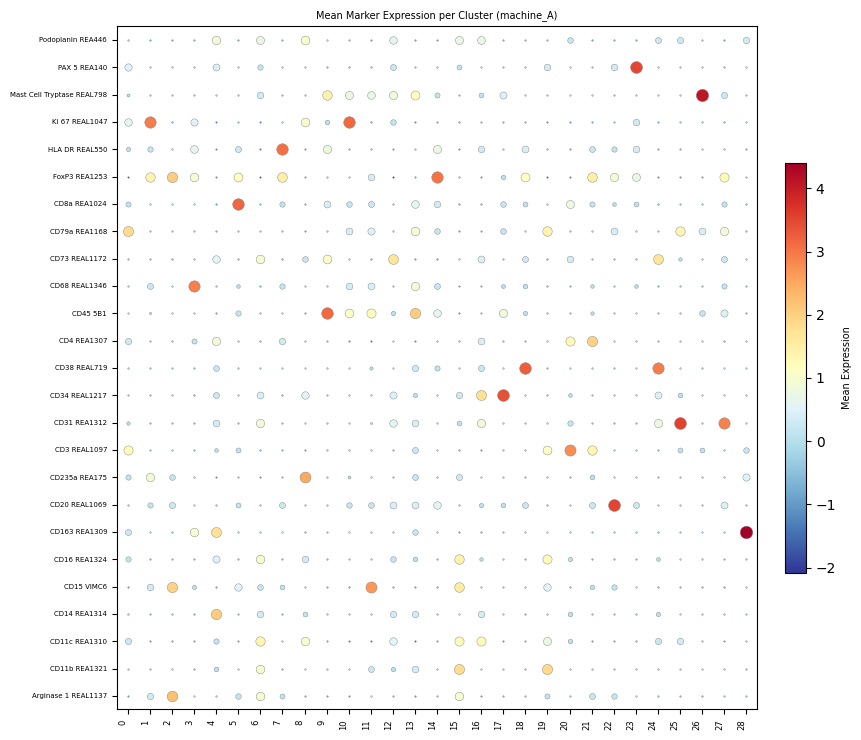

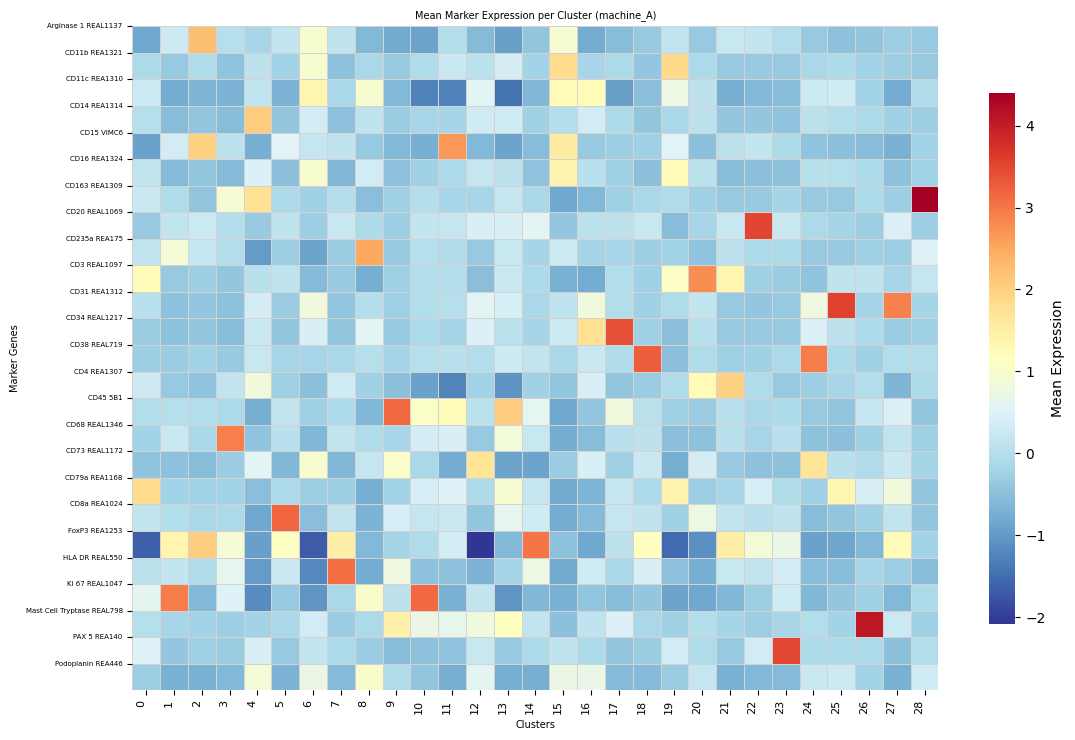

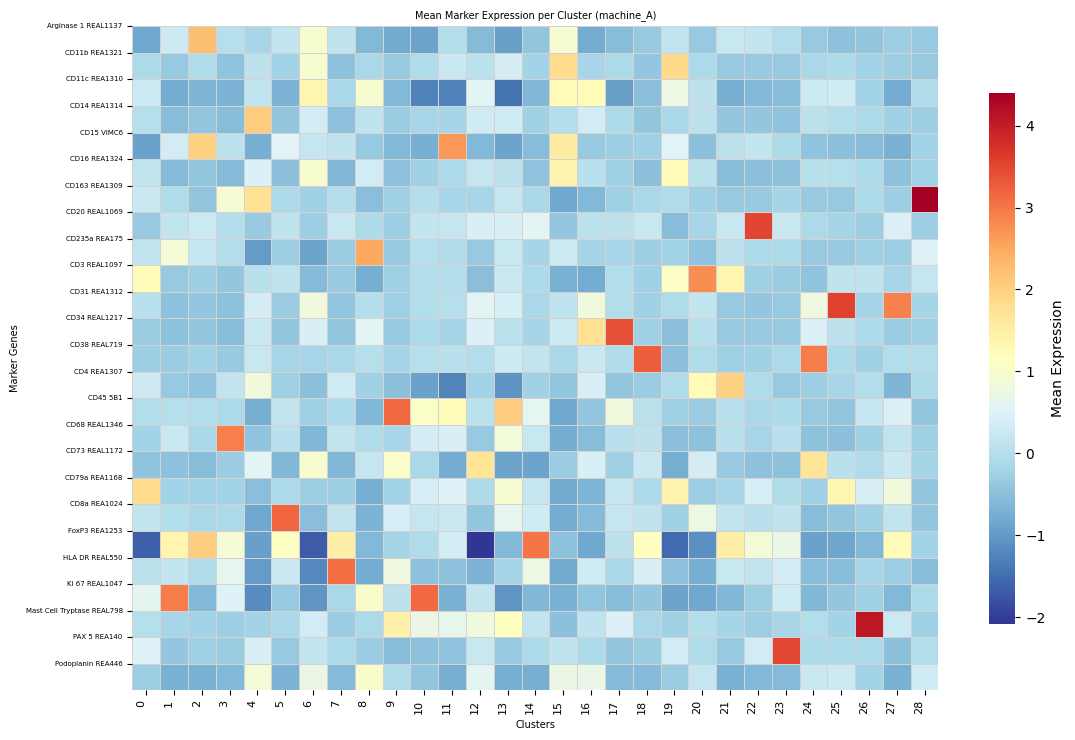

In [8]:
# Compute cluster means
cluster_means = prepare_cluster_means(
    adata, selected_markers, unselected_features, cluster_key="leiden"
)

x_labels = cluster_means.index.tolist()
y_labels = list(selected_markers)
y_labels_all = list(selected_markers) + unselected_features

# Dot plot (selected markers)
plot_dotplot(
    cluster_means, x_labels, y_labels,
    save_path=output_dir / "dotplot.svg",
    title=f"Mean Marker Expression per Cluster ({MACHINE})",
)

# Heatmap (selected markers)
plot_heatmap(
    cluster_means, x_labels, y_labels,
    save_path=output_dir / "heatmap.svg",
    title=f"Mean Marker Expression per Cluster ({MACHINE})",
)

## Top Markers & Save Outputs

In [9]:
# Differential expression: top markers per cluster
top_markers = compute_top_markers(adata, groupby="leiden", top_k=5)
display(top_markers)
top_markers.to_csv(output_dir / "top_markers.csv", index=False)

# Save AnnData
save_adata(adata, output_dir / "adata.h5ad")

# Save per-ROI cluster assignment CSVs
roi_dir = output_dir / "roi_assignments"
save_roi_assignments(adata, roi_dir, region_col="unique_region")

print(f"\n✓ Stage 3 complete for machine '{MACHINE}'")
print(f"  Outputs: {output_dir}")

/home/hp/projects/multiplex_imaging_analysis/.venv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/hp/projects/multiplex_imaging_analysis/.venv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/hp/projects/multiplex_imaging_analysis/.venv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/hp/projects/multiplex_imaging_analysis/.venv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/hp/projects/multiplex_imaging_analysis/.venv/lib/python3.10/site-packages/scanpy/tools/_rank_genes

,group,names,scores,logfoldchanges,pvals,pvals_adj
15,0,CD11b REA1321,-8.838554,9.268686,9.696512e-19,1.101876e-18
8,0,Ki 67 REAL1047,22.292393,3.587761,4.379490e-110,6.842953e-110
18,0,CD73 REAL1172,-30.256397,2.392553,4.298349e-201,7.163915e-201
11,0,HLA DR REAL550,13.965131,1.361694,2.544375e-44,3.180469e-44
13,0,Podoplanin REA446,2.181643,0.708503,2.913590e-02,3.034990e-02
...,...,...,...,...,...,...
700,28,CD163 REA1309,5.990355,17.944944,2.093837e-09,5.234594e-08
702,28,CD235a REA175,2.696776,6.027806,7.001443e-03,4.256467e-02
720,28,CD11b REA1321,-1.968221,4.780737,4.904256e-02,1.532580e-01
711,28,Arginase 1 REAL1137,0.222839,3.466484,8.236609e-01,8.952836e-01


Saved AnnData → experiments/my_experiment/stage3_clustering/machine_A/adata.h5ad
Saved 10 per-ROI assignment files → experiments/my_experiment/stage3_clustering/machine_A/roi_assignments

✓ Stage 3 complete for machine 'machine_A'
  Outputs: experiments/my_experiment/stage3_clustering/machine_A
